## Grape Disease Classification Classification


In [1]:
# Test to check if Jupyter Notebook is working correctly
import sys
import numpy as np
import matplotlib.pyplot as plt

print("Jupyter Notebook is working!")
print(f"Python version: {sys.version}")
print(f"NumPy version: {np.__version__}")

# Simple test calculation
test_array = np.array([1, 2, 3, 4, 5])
print(f"NumPy calculation: Sum of {list(test_array)} = {test_array.sum()}")


print("All tests passed! Notebook is ready to use.")

Jupyter Notebook is working!
Python version: 3.10.12 (main, Jan  8 2026, 06:52:19) [GCC 11.4.0]
NumPy version: 1.26.4
NumPy calculation: Sum of [1, 2, 3, 4, 5] = 15
All tests passed! Notebook is ready to use.


First of all import some libraries that are used throughout the notebook:

In [2]:
# Install missing packages with proper CUDA support
packages_to_check = {
    'gdown': 'gdown',
    'tqdm': 'tqdm',
    'ipywidgets': 'ipywidgets',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'numpy': 'numpy'
}

for package_name, pip_name in packages_to_check.items():
    try:
        if package_name == 'sklearn':
            from sklearn.metrics import confusion_matrix  # Test specific import
        elif package_name == 'matplotlib':
            import matplotlib.pyplot as plt  
        else:
            __import__(package_name)
        print(f"{package_name} already available")
    except ImportError:
        print(f"Installing {pip_name}...")
        !pip install -q {pip_name}

# Check PyTorch and install if missing with auto-detected CUDA support
try:
    import torch
    import torchvision
    print(f"PyTorch {torch.__version__} already installed")
    if torch.cuda.is_available():
        print(f"CUDA {torch.version.cuda} support available")
        print(f"GPU device: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not found. Detecting system CUDA version...")

    # Detect CUDA version
    import subprocess
    cuda_version = None
    try:
        # Try nvidia-smi first
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
        if result.returncode == 0:
            for line in result.stdout.split('\n'):
                if 'CUDA Version:' in line:
                    cuda_version = line.split('CUDA Version:')[1].strip().split()[0]
                    break

        # Try nvcc as backup
        if not cuda_version:
            result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
            if result.returncode == 0:
                for line in result.stdout.split('\n'):
                    if 'release' in line.lower():
                        # Extract version like "12.5" from "release 12.5, V12.5.82"
                        cuda_version = line.split('release')[1].split(',')[0].strip()
                        break
    except:
        pass

    # Determine PyTorch index URL based on CUDA version
    if cuda_version:
        major_minor = cuda_version.split('.')[:2]
        cuda_short = ''.join(major_minor)  # "12.5" -> "125", "12.4" -> "124"
        index_url = f"https://download.pytorch.org/whl/cu{cuda_short}"
        print(f"Installing PyTorch with CUDA {cuda_version} support...")
    else:
        index_url = "https://download.pytorch.org/whl/cpu"
        print("CUDA not detected, installing CPU-only PyTorch...")

    !pip install -q torch torchvision torchaudio --index-url {index_url}

# Verify all imports work
print("\nVerifying all imports...")
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    from torch.utils.data import DataLoader, Dataset, Subset
    from torch.quantization import fuse_modules, get_default_qconfig, get_default_qat_qconfig, prepare, prepare_qat, convert
    import torch.nn.utils.prune as prune
    import torchvision
    import torchvision.transforms as transforms
    import torchvision.models as models
    from torchvision.models.resnet import ResNet
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    from sklearn.model_selection import train_test_split
    import numpy as np
    
    # Try to import tqdm for notebooks with fallback to regular tqdm
    try:
        from tqdm.notebook import tqdm
        print("Using tqdm.notebook (with progress bar widgets)")
    except ImportError:
        from tqdm import tqdm
        print("Using standard tqdm (ipywidgets not available)")
    
    import datetime
    import copy
    import os
    import gdown
    import random
    import time
    import pandas as pd
    import seaborn as sns
    from sklearn.manifold import TSNE
    from torch.cuda.amp import autocast, GradScaler

    print("All imports successful!")

    # Show system info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"CUDA version: {torch.version.cuda}")
        print(f"GPU: {torch.cuda.get_device_name(0)}")

except ImportError as e:
    print(f"Import error: {e}")


gdown already available
tqdm already available
ipywidgets already available
seaborn already available
sklearn already available
pandas already available
matplotlib already available
numpy already available
PyTorch 2.9.1+cu128 already installed
CUDA 12.8 support available
GPU device: NVIDIA L4

Verifying all imports...
Using tqdm.notebook (with progress bar widgets)
All imports successful!
PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
GPU: NVIDIA L4


In [3]:
# Load the raw datasets

try:
    print("loading the dataset...")
    
    # Function to check if file has valid image extension (case-insensitive)
    def is_valid_image_file(filename):
        valid_extensions = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
        return filename.lower().endswith(valid_extensions)
    
    raw_train_val_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train',
        is_valid_file=is_valid_image_file
    )
    raw_test_dataset = torchvision.datasets.ImageFolder(
        root='/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test',
        is_valid_file=is_valid_image_file
    )

    print("Dataset loaded successfully.")
    print(f"Training samples: {len(raw_train_val_dataset)}")
    print(f"Test samples: {len(raw_test_dataset)}")
    print(f"Classes: {raw_train_val_dataset.classes}")
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

loading the dataset...
Dataset loaded successfully.
Training samples: 3248
Test samples: 814
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']


In [4]:
# Verify the dataset sizes
train_val_size = len(raw_train_val_dataset)
test_size = len(raw_test_dataset)
total_size = train_val_size + test_size

print(f"Verification of Dataset Size:")
print("-" * 30)
print(f"Images in Training & Validation set: {train_val_size}")
print(f"Images in Test set: {test_size}")
print(f"Total images in the dataset: {total_size}")

# The paper's table shows a total of 7349 images.
# The torchvision split uses the same convention.
if train_val_size == 7222 and test_size == 1805:
    print("\n The dataset size matches the official numbers from the paper.")
else:
    print("\n Warning: The dataset size does not match the official numbers.")

Verification of Dataset Size:
------------------------------
Images in Training & Validation set: 3248
Images in Test set: 814
Total images in the dataset: 4062



### Data Preprocessing and Augmentation

In [5]:
class UnNormalize(object):
    """Reverses the normalization on a tensor image for visualization."""
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        # Create a copy to avoid modifying the original tensor
        tensor = tensor.clone()
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

def visualize_transforms(dataset, transform, title):
    """
    Applies a given transformation pipeline to a few sample images and displays
    the original versus the augmented versions.
    """
    # Try to find normalization parameters
    normalize_transform = None
    mean, std = None, None

    # First, try to find Normalize in the direct pipeline
    for t in transform.transforms:
        if isinstance(t, transforms.Normalize):
            normalize_transform = t
            mean, std = t.mean, t.std
            break

    # If not found, check if there's a nested transform (like weights.transforms())
    if normalize_transform is None:
        for t in transform.transforms:
            if hasattr(t, 'transforms'):  # It's a nested Compose
                for nested_t in t.transforms:
                    if isinstance(nested_t, transforms.Normalize):
                        normalize_transform = nested_t
                        mean, std = nested_t.mean, nested_t.std
                        break
                if normalize_transform:
                    break

    # If still not found, use ImageNet defaults (common for pretrained models)
    if normalize_transform is None:
        print(f"Warning: Normalize transform not found. Using ImageNet defaults.")
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.128, 0.225]

    un_normalizer = UnNormalize(mean=mean, std=std)

    # Get a few random images from the raw dataset
    num_images_to_show = 4
    indices = np.random.choice(len(dataset), num_images_to_show, replace=False)

    fig, axes = plt.subplots(num_images_to_show, 5, figsize=(15, 2.5 * num_images_to_show))
    fig.suptitle(title, fontsize=16)

    for i, idx in enumerate(indices):
        original_image, _ = dataset[idx]

        # Display the original image
        ax = axes[i, 0]
        ax.imshow(original_image)
        ax.set_title("Original")
        ax.axis('off')

        # Display 4 augmented versions
        for j in range(1, 5):
            ax = axes[i, j]
            augmented_tensor = transform(original_image)
            unnormalized_tensor = un_normalizer(augmented_tensor.clone())

            # Clamp values to [0, 1] range for display
            unnormalized_tensor = torch.clamp(unnormalized_tensor, 0, 1)

            augmented_image_display = unnormalized_tensor.permute(1, 2, 0)
            ax.imshow(augmented_image_display)
            ax.set_title(f"Augmented {j}")
            ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

Global Utilities


In [6]:
def evaluate_model(model, data_loader, criterion, device, desc="Evaluating"):
    """A standardized evaluation function to be used across all experiments."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(data_loader, desc=desc)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=torch.cuda.is_available()):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{running_loss/total:.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    final_loss = running_loss / len(data_loader.dataset)
    final_acc = 100. * correct / total
    return final_loss, final_acc, all_preds, all_labels

def print_model_size(model, label):
    """Saves a model to a temporary file to measure its size on disk."""
    temp_path = f"temp_{label}.pth"
    torch.save(model.state_dict(), temp_path)
    size_mb = os.path.getsize(temp_path) / (1024 * 1024)
    print(f"Size of {label} model: {size_mb:.2f} MB")
    os.remove(temp_path)
    return size_mb

In [7]:

# Define some reusable functions to download a file from Google Drive and to load a training history from a CSV file
def download_from_gdrive(file_id, output_path, file_label):
    """Downloads a file from Google Drive if it doesn't already exist."""
    if not os.path.exists(output_path):
        print(f"Downloading {file_label} to '{output_path}'...")
        gdown.download(id=file_id, output=output_path, quiet=False)
        print(f"{file_label} download complete.")
    else:
        print(f"{file_label} file '{output_path}' already exists. Skipping download.")

def load_training_history_from_csv(log_path):
    """Loads a training history log from a CSV file into a dictionary of lists."""
    try:
        log_df = pd.read_csv(log_path)
        # Ensure all expected columns are present, fill with empty lists if not
        history = {
            'train_loss': log_df.get('train_loss', pd.Series([])).tolist(),
            'train_accuracy': log_df.get('train_accuracy', pd.Series([])).tolist(),
            'val_loss': log_df.get('val_loss', pd.Series([])).tolist(),
            'val_accuracy': log_df.get('val_accuracy', pd.Series([])).tolist(),
            'learning_rate': log_df.get('learning_rate', pd.Series([])).tolist()
        }
        if history['train_loss']:
             print(f"Successfully loaded training history for {len(history['train_loss'])} epochs from '{log_path}'.")
        else:
             print(f"Warning: Could not load complete history from '{log_path}'. Check file content.")
        return history
    except FileNotFoundError:
        print(f"Error: The log file '{log_path}' was not found.")
        # Return empty history to avoid crashing subsequent code
        return {key: [] for key in ['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'learning_rate']}

In [8]:
# We ensure reproducibility in our experiments
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    print(f"Random seed set to {seed}")

# Set the seed for the entire notebook
SEED = 42
set_seed(SEED)

Random seed set to 42


#### A Two-Stage Fine-Tuning Strategy


In [9]:
# ResNet18 Fine-Tuning Configuration
# ==========================================
# BASELINE COMPARISON WITH MOBILENETV2
# ==========================================
# Using EXACT same configuration as MobileNetV2_128 for fair comparison
# ==========================================

NUM_CLASSES = 4
BATCH_SIZE = 64  # Training batch size (same as MobileNetV2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1: Warm-up (Training the classifier head only)
STAGE1_EPOCHS = 10       # 10 epochs for warm-up (matches MobileNetV2)
STAGE1_LR = 1e-3         # Higher LR for new classifier head
STAGE1_PATIENCE = 5      # Early stopping patience
STAGE1_MODEL_PATH_RESNET = "transfer_learning_resnet18_128.pth"

# Stage 2: Full Fine-tuning (All layers unfrozen)
STAGE2_EPOCHS = 40       # 40 epochs for full fine-tuning (matches MobileNetV2)
STAGE2_LR = 1e-4         # Lower LR for fine-tuning pretrained weights
STAGE2_PATIENCE = 10     # More patience for fine-tuning
STAGE2_MODEL_PATH_RESNET = "finetuned_ResNet18_128.pth"

# Regularization (identical to MobileNetV2)
LABEL_SMOOTHING_FT = 0.1    # Label smoothing for better generalization
WEIGHT_DECAY_FT = 1e-4      # L2 regularization



In [10]:
# Define a wrapper class to apply transforms to a Subset
# This is needed because torch.utils.data.random_split returns a Subset object
# which doesn't directly support transformations

class TransformedSubset(Dataset):
    """
    Wrapper class to apply transforms to a Subset.
    
    Args:
        subset: A torch.utils.data.Subset object
        transform: Optional transform to be applied on a sample
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)
    
    @property
    def classes(self):
        return self.subset.dataset.classes

print("TransformedSubset class defined successfully.")

TransformedSubset class defined successfully.


In [11]:
# Data preparation for fine-tuning
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)
    @property
    def classes(self):
        return self.subset.dataset.classes

# ==========================================
# ESP32-S3 OPTIMIZED TRANSFORMS FOR FINE-TUNING
# ==========================================
# Using 128x128 input size (optimal for ESP32 deployment)
# ImageNet normalization is maintained for transfer learning
# ==========================================

# Training transforms with strong augmentation
train_transform_ft = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25, interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.15),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.128, 0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3))
])

# Validation/Test transforms (no augmentation)
test_transform_ft = transforms.Compose([
    transforms.Resize(144),  # 12.5% larger than target size for center crop
    transforms.CenterCrop(128),  # 128x128 for ESP32 deployment
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.128, 0.225])
])

print("--- Validation/Test Transforms ---")
print(test_transform_ft)

print("\n--- Training Transforms (with Augmentation) ---")
print(train_transform_ft)


# Load the grape disease dataset from local directory
train_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/train'
test_dir = '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/dataset/grape_dataset/test'

# Load training-validating and testing datasets from local folders
raw_train_val_dataset = torchvision.datasets.ImageFolder(root=train_dir, transform=None)
raw_test_dataset = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

print(f"\nDataset loaded from local directory:")
print(f"Training/Validation set: {len(raw_train_val_dataset)} images")
print(f"Test set: {len(raw_test_dataset)} images")
print(f"Classes: {raw_train_val_dataset.classes}")

# Create deterministic splits (using same seed as training from scratch for consistency)
# 85-15 split for training and validation of the training set
#Get Labels
targets = [s[1] for s in raw_train_val_dataset.samples]
# Stratified split
train_idx, val_idx = train_test_split(
    list(range(len(targets))),
    test_size=0.15,
    stratify=targets,
    random_state=42
)
# Create Train and Validation subsets
from torch.utils.data import Subset
train_subset = Subset(raw_train_val_dataset, train_idx)
val_subset = Subset(raw_train_val_dataset, val_idx)


# Apply transforms to subsets
train_dataset_ft = TransformedSubset(train_subset, train_transform_ft)
val_dataset_ft = TransformedSubset(val_subset, test_transform_ft)
test_dataset_ft = TransformedSubset(raw_test_dataset, test_transform_ft)

# Create a dataset for visualization that has NO transforms
raw_test_dataset_for_viz = torchvision.datasets.ImageFolder(root=test_dir, transform=None)

# Create DataLoaders
train_loader_ft = DataLoader(train_dataset_ft, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader_ft = DataLoader(val_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader_ft = DataLoader(test_dataset_ft, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"\n Dataset Split Summary:")
print(f"   Train: {len(train_dataset_ft)} images ({len(train_loader_ft)} batches)")
print(f"   Validation: {len(val_dataset_ft)} images ({len(val_loader_ft)} batches)")
print(f"   Test: {len(test_dataset_ft)} images ({len(test_loader_ft)} batches)")
print(f"   Classes: {raw_train_val_dataset.classes}")
print(f"\n DataLoaders created successfully.")

--- Validation/Test Transforms ---
Compose(
    Resize(size=144, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(128, 128))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.128, 0.225])
)

--- Training Transforms (with Augmentation) ---
Compose(
    RandomResizedCrop(size=(128, 128), scale=(0.5, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-25.0, 25.0], interpolation=bilinear, expand=False, fill=0)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=(-0.15, 0.15))
    RandomGrayscale(p=0.15)
    RandomPerspective(p=0.4)
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.5))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.128, 0.225])
    RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0, inplace=False)
)

Dataset loaded from local directory:
Training/V

In [12]:
# We define the model to fine-tune
class FineTuneResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.7):
        super().__init__()
        # 1. Load the MobileNetV2 model with the best available pretrained weights
        # 1. Load the ResNet18 model with the best available pretrained weights
        weights = torchvision.models.ResNet18_Weights.DEFAULT
        self.resnet = torchvision.models.resnet18(weights=weights)

        # 2. Freeze all parameters in the pretrained backbone
        for param in self.resnet.parameters():
            param.requires_grad = False

        # 3. Replace the final classifier with a new head
        # ResNet18's classifier is at self.resnet.fc
        in_features = self.resnet.fc.in_features  # 512 for ResNet18
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

    def unfreeze_all(self):
        """A helper method to unfreeze all layers for the second stage of training."""
        print("Unfreezing all model layers for fine-tuning...")
        for param in self.resnet.parameters():
            param.requires_grad = True

model_ft_resnet = FineTuneResNet(num_classes=NUM_CLASSES).to(DEVICE)

# Verify which parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_resnet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_resnet.parameters())
print(f"Initially, only the classifier head is trainable.")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Initially, only the classifier head is trainable.
Trainable parameters: 2,052
Total parameters: 11,178,564


In [14]:
# early-stopping mechanism implementation
class EarlyStopper:
    """Handles early stopping and saves the best model based on validation loss."""
    def __init__(self, patience=7, min_delta=0, model_save_path="best_model.pth", min_relative_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta  # Absolute minimum improvement
        self.min_relative_delta = min_relative_delta  # Relative improvement (e.g., 0.1% = 0.001)
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.model_save_path = model_save_path

    def __call__(self, val_loss, model):
        # Use relative improvement when loss is very small, absolute otherwise
        if self.best_loss < 0.01:  # For very small losses, use relative improvement
            improvement_threshold = self.best_loss * (1 - self.min_relative_delta)
            is_improvement = val_loss < improvement_threshold
        else:  # For larger losses, use absolute improvement
            is_improvement = val_loss < self.best_loss - self.min_delta
        
        if is_improvement:
            improvement_pct = ((self.best_loss - val_loss) / max(self.best_loss, 1e-8)) * 100
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.model_save_path)
            print(f"New best model saved with validation loss: {val_loss:.4f} (improved by {improvement_pct:.2f}%)")
        else:
            self.counter += 1
            print(f"No improvement for {self.counter}/{self.patience} epochs. Best loss: {self.best_loss:.4f}")
            if self.counter >= self.patience:
                print("--- Early stopping triggered! ---")
                self.early_stop = True

# training and validation loop
def train_validate_loop_ft(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, early_stopper, device):
    """A complete training and validation loop for one stage of fine-tuning."""
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # training
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Training]")
        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = 100 * train_correct / train_total
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        # validation
        epoch_val_loss, epoch_val_acc, _, _ = evaluate_model(model, val_loader, criterion, device, desc=f"Epoch {epoch+1}/{num_epochs} [Validation]")
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}")

        scheduler.step(epoch_val_loss)
        early_stopper(epoch_val_loss, model)
        if early_stopper.early_stop:
            break

    return history

In [15]:
# fine-tuning execution, train stage1 and train stage2:

# History lists
history_stage1_resnet, history_stage2_resnet = {}, {}

print("Starting ResNet fine-tuning...")

# Stage 1: Warm-up
print("\n" + "="*70)
print("STAGE 1: Traning classifier head only (frozen backbone)")
print("="*70)
print(f"Learning Rate: {STAGE1_LR}")
print(f"Weight Decay: {WEIGHT_DECAY_FT}")
print(f"Label Smoothing: {LABEL_SMOOTHING_FT}")
print(f"Early Stopping Patience: {STAGE1_PATIENCE}")
print()

criterion_ft = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING_FT)

optimizer_stage1_resnet = optim.AdamW(model_ft_resnet.resnet.fc.parameters(), lr=STAGE1_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage1_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage1_resnet, 'min', factor=0.1, patience=2)
stopper_stage1_resnet = EarlyStopper(patience=STAGE1_PATIENCE, model_save_path=STAGE1_MODEL_PATH_RESNET)

history_stage1_resnet = train_validate_loop_ft(
    model_ft_resnet, train_loader_ft, val_loader_ft, optimizer_stage1_resnet, criterion_ft, scheduler_stage1_resnet,
    num_epochs=STAGE1_EPOCHS, early_stopper=stopper_stage1_resnet, device=DEVICE
)

# Stage 2: Full fine-tuning
print("\n" + "="*50)
print("STAGE 2: Fine-tuning all layers")
print("="*50)
print(f"Loading best model from Stage 1: {STAGE1_MODEL_PATH_RESNET}")
model_ft_resnet.load_state_dict(torch.load(STAGE1_MODEL_PATH_RESNET))
model_ft_resnet.unfreeze_all()

# Verify all parameters are trainable
trainable_params = sum(p.numel() for p in model_ft_resnet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_ft_resnet.parameters())
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} (100%)")
print()

# Use STAGE2_LR constant instead of hardcoded value
optimizer_stage2_resnet = optim.AdamW(model_ft_resnet.parameters(), lr=STAGE2_LR, weight_decay=WEIGHT_DECAY_FT)
scheduler_stage2_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_stage2_resnet, 'min', factor=0.2, patience=3)
stopper_stage2_resnet = EarlyStopper(patience=STAGE2_PATIENCE, model_save_path=STAGE2_MODEL_PATH_RESNET)

history_stage2_resnet = train_validate_loop_ft(
    model_ft_resnet, train_loader_ft, val_loader_ft, optimizer_stage2_resnet, criterion_ft, scheduler_stage2_resnet,
    num_epochs=STAGE2_EPOCHS, early_stopper=stopper_stage2_resnet, device=DEVICE
)

Starting ResNet fine-tuning...

STAGE 1: Traning classifier head only (frozen backbone)
Learning Rate: 0.001
Weight Decay: 0.0001
Label Smoothing: 0.1
Early Stopping Patience: 5



Epoch 1/10 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 1/10 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 35.40% | Val Acc: 67.42% | Val Loss: 0.9196
New best model saved with validation loss: 0.9196 (improved by nan%)


Epoch 2/10 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

...

Epoch 39/40 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 39 | Train Acc: 98.51% | Val Acc: 99.80% | Val Loss: 0.3543
New best model saved with validation loss: 0.3543 (improved by 0.11%)


Epoch 40/40 [Training]:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 40/40 [Validation]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 40 | Train Acc: 98.66% | Val Acc: 100.00% | Val Loss: 0.3547
No improvement for 1/10 epochs. Best loss: 0.3543


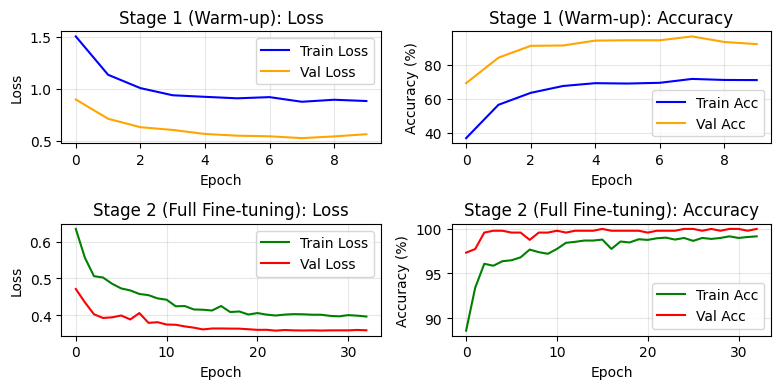

Training curves saved as 'resnet18_training_curves.png'


In [63]:
# Visualize ResNet18 Training Progress

# Plot Stage 1 and Stage 2 training curves
fig, axes = plt.subplots(2, 2, figsize=(8, 4))

# Stage 1: Loss
axes[0, 0].plot(history_stage1_resnet['train_loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_stage1_resnet['val_loss'], label='Val Loss', color='orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Stage 1 (Warm-up): Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Stage 1: Accuracy
axes[0, 1].plot(history_stage1_resnet['train_acc'], label='Train Acc', color='blue')
axes[0, 1].plot(history_stage1_resnet['val_acc'], label='Val Acc', color='orange')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Stage 1 (Warm-up): Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Stage 2: Loss
axes[1, 0].plot(history_stage2_resnet['train_loss'], label='Train Loss', color='green')
axes[1, 0].plot(history_stage2_resnet['val_loss'], label='Val Loss', color='red')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Stage 2 (Full Fine-tuning): Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Stage 2: Accuracy
axes[1, 1].plot(history_stage2_resnet['train_acc'], label='Train Acc', color='green')
axes[1, 1].plot(history_stage2_resnet['val_acc'], label='Val Acc', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Stage 2 (Full Fine-tuning): Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet18_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training curves saved as 'resnet18_training_curves.png'")

In [ ]:
import os

# Model paths
models = {
    'ResNet18 .pth': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/ResNet/finetuned_ResNet18_128.pth',
    'Stage1 checkpoint': '/home/ubuntu/edge-ai-vineyard-monitoring/dd_cnn/Model_training/ResNet/transfer_learning_resnet18_128.pth'
}

print("ResNet18 Model Sizes")
print("Model                  Size (MB)")
print("-" * 55)
for name, path in models.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"{name:<20} {size_mb:>8.2f}")
    else:
        print(f"{name:<20} NOT FOUND")

ResNet18 Model Sizes
Model                  Size (MB)
-------------------------------------------------------
ResNet18 .pth           42.72
Stage1 checkpoint       42.72
